In [1]:
print("I am ready to do research")

I am ready to do research


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)

pandas: 2.3.3
numpy: 2.3.5
matplotlib: 3.10.6
seaborn: 0.13.2


In [5]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
path=r"C:\Users\tbend\OneDrive\Documents\GitHub\pediatric-obesity-ml\\"
demo=pd.read_sas(path + "DEMO_L.XPT",format="xport",encoding="utf-8")
bmx=pd.read_sas(path + "BMX_L.XPT", format="xport", encoding="utf-8")
paq=pd.read_sas(path+"PAQ_L.XPT",format="xport",encoding="utf-8")
paqy=pd.read_sas(path+"PAQY_L.XPT",format="xport",encoding="utf-8")
dbq=pd.read_sas(path+"DBQ_L.XPT",format="xport",encoding="utf-8")
print("DEMO_L rows:",len(demo))
print("BMX_L rows:",len(demo))
print("PAQ_L rows:",len(demo))
print("PAQY_L rows:",len(demo))
print("DBQ_L rows:",len(demo))
print ("All files loaded successfully") 


DEMO_L rows: 11933
BMX_L rows: 11933
PAQ_L rows: 11933
PAQY_L rows: 11933
DBQ_L rows: 11933
All files loaded successfully


In [4]:
master=demo.merge(bmx,on="SEQN",how="left")
master=master.merge(paq,on="SEQN",how="left")
master=master.merge(paqy,on="SEQN",how="left")
master=master.merge(dbq,on="SEQN",how="left")
print("Totalrows in master dataset:",len(master))
print("Total columns in master dataset:",len(master.columns))
print("Merge successful")


Total rows in master dataset: 11933
Total columns in master dataset: 83
Merge successful


In [9]:
children=master[master["RIDAGEYR"]<=19]
children=children[children["RIDAGEYR"]>=2] 
children=children[children["RIDRETH3"].isin([1,2,4])]
print("Total children in the study:",len(children))
print("")
print("Breakdown by race/ethnicity:")
print(children["RIDRETH3"].value_counts())

Total children in the study: 1627

Breakdown by race/ethnicity:
RIDRETH3
4.0    563
2.0    534
1.0    530
Name: count, dtype: int64


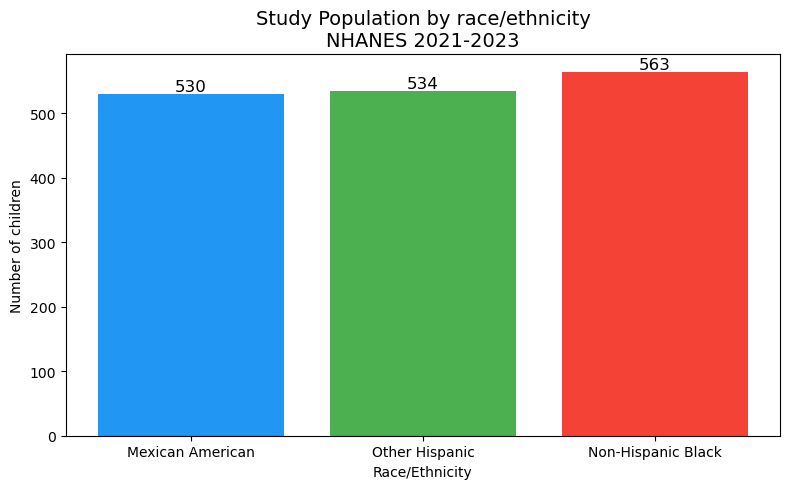

Figure 1 saved


In [10]:
race_labels=["Mexican American","Other Hispanic","Non-Hispanic Black"]
race_counts=[530,534,563]
colors=["#2196F3","#4CAF50","#F44336"]
plt.figure(figsize=(8,5))
plt.bar(race_labels,race_counts,color=colors)
plt.title("Study Population by race/ethnicity\nNHANES 2021-2023",fontsize=14)
plt.ylabel("Number of children")
plt.xlabel("Race/Ethnicity")
for i,v in enumerate(race_counts):
    plt.text(i,v+5,str(v),ha="center",fontsize=12)
plt.tight_layout()
plt.savefig("figure1_population.png")
plt.show()
print("Figure 1 saved")


In [12]:
print("BMI Category Breakdown:")
print(children["BMDBMIC"].value_counts())
print("")
total=len(children)
obese=len(children[children["BMDBMIC"]==4])
overweight=len(children[children["BMDBMIC"]==3])
normal=len(children[children["BMDBMIC"]==2])
underweight=len(children[children["BMDBMIC"]==1])
print("Underweight:", underweight, "(",round(underweight/total*100,1),"%)")
print("Normal:",normal,"(",round(normal/total*100,1),"%)")
print("Overweight:",overweight,"(",round(overweight/total*100,1),"%)")
print("Obese:",obese,"(",round(obese/total*100,1),"%)")


BMI Category Breakdown:
BMDBMIC
2.0    583
4.0    320
3.0    175
1.0     24
Name: count, dtype: int64

Underweight: 24 ( 1.5 %)
Normal: 583 ( 35.8 %)
Overweight: 175 ( 10.8 %)
Obese: 320 ( 19.7 %)


In [15]:
print("Obesity rate by race/ethnicity:")
print("")
for race_code,race_name in[(1.0,"Mexican American"),
                           (2.0,"Other Hispanic"),
                           (4.0,"Non-Hispanic Black")]:
    race_group=children[children["RIDRETH3"]==race_code]
    total_race=len(race_group)
    obese_race=len(race_group[race_group["BMDBMIC"]==4])
    pct=round(obese_race/total_race*100,1)
    print(f"{race_name}: {obese_race} obese out of {total_race}({pct}%)")
    

Obesity rate by race/ethnicity:

Mexican American: 94 obese out of 530(17.7%)
Other Hispanic: 106 obese out of 534(19.9%)
Non-Hispanic Black: 120 obese out of 563(21.3%)


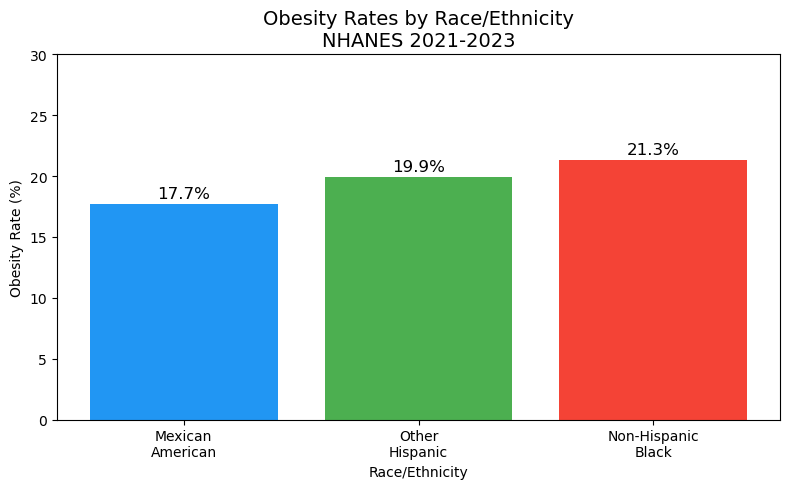

Figure 2 saved


In [18]:
race_names= ["Mexican\nAmerican", "Other\nHispanic", "Non-Hispanic\nBlack"]
obesity_rates= [17.7, 19.9, 21.3]
colors= ["#2196F3", "#4CAF50", "#F44336"]
plt.figure(figsize=(8, 5))
plt.bar(race_names, obesity_rates, color=colors)
plt.title("Obesity Rates by Race/Ethnicity\nNHANES 2021-2023", fontsize=14)
plt.ylabel("Obesity Rate (%)")
plt.xlabel("Race/Ethnicity")
plt.ylim(0, 30)
for i,v in enumerate (obesity_rates):
    plt.text(i, v+ 0.5, str(v)+"%",ha="center", fontsize=12)
plt.tight_layout()
plt.savefig("figure2_obesity_rates.png")
plt.show()
print("Figure 2 saved")
